<a href="https://colab.research.google.com/github/AngieVenta/AngieVenta/blob/main/DS_C7SC4_GloriaAngelicaVenta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reto DS_C7_SC4 — Clasificador Gatos vs. Perros con Deep Learning (PyTorch)

## 1. Configuración, semillas y verificación de GPU

In [2]:
import os
import random
import time
import zipfile
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Version de PyTorch : {torch.__version__}")
print(f"CUDA disponible    : {torch.cuda.is_available()}")
print(f"Dispositivo activo : {device}")

if device.type == "cuda":
    print(f"GPU                : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"Memoria GPU        : {total_mem:.1f} GB")
else:
    print(" no hay GPU asignada.")

Version de PyTorch : 2.11.0+cu128
CUDA disponible    : True
Dispositivo activo : cuda
GPU                : Tesla T4
Memoria GPU        : 14.6 GB


## 2. Carga y descompresión de la base de datos

In [3]:
ZIP_PATH = "/content/Catsvsdogs.zip"
EXTRACT_DIR = "/content/dataset"
DATA_ROOT = os.path.join(EXTRACT_DIR, "catsvsdogs")

if not os.path.isdir(DATA_ROOT):
    print(f"Descomprimiendo {ZIP_PATH} ...")
    start = time.time()
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print("La carpeta ya estaba descomprimida")

print(f"Raiz de datos: {DATA_ROOT}")
print(f"Subcarpetas  : {sorted(os.listdir(DATA_ROOT))}")

Descomprimiendo /content/Catsvsdogs.zip ...
Raiz de datos: /content/dataset/catsvsdogs
Subcarpetas  : ['cats', 'dogs']


## 3. Análisis exploratorio de la base de datos


In [4]:
CLASSES = ["cats", "dogs"]
VALID_EXT = (".jpg", ".jpeg", ".png", ".bmp")

file_index = {}
non_image_files = []

for cls in CLASSES:
    folder = os.path.join(DATA_ROOT, cls)
    all_files = sorted(os.listdir(folder))
    images = [f for f in all_files if f.lower().endswith(VALID_EXT)]
    others = [f for f in all_files if not f.lower().endswith(VALID_EXT)]
    file_index[cls] = images
    non_image_files += [os.path.join(cls, f) for f in others]

total = sum(len(v) for v in file_index.values())

print("Conteo de imagenes por clase")
for cls, files in file_index.items():
    print(f"  {cls:<6}: {len(files):>5} imagenes  ({len(files)/total:.1%})")
print(f"  {'TOTAL':<6}: {total:>5} imagenes")

print(f"\n Archivos que NO son imagenes: {len(non_image_files)}")
for f in non_image_files:
    print(f"  {f}")


Conteo de imagenes por clase
  cats  :  2400 imagenes  (49.0%)
  dogs  :  2495 imagenes  (51.0%)
  TOTAL :  4895 imagenes

 Archivos que NO son imagenes: 3
  cats/Abyssinian_100.mat
  cats/Abyssinian_101.mat
  cats/Abyssinian_102.mat


In [5]:
# Verificacion de integridad y de modos de color
# Recorremos TODAS las imagenes para detectar archivos corruptos
#Tambien contamos los modos de color: las imagenes en escala de grises (L), con paleta (P) o con canal alfa (RGBA)

corrupt_files, color_modes, sizes = [], Counter(), []

for cls, files in file_index.items():
    for fname in files:
        path = os.path.join(DATA_ROOT, cls, fname)
        try:
            with Image.open(path) as img:
                color_modes[img.mode] += 1
                sizes.append(img.size)
        except Exception as exc:
            corrupt_files.append((path, type(exc).__name__))

print(f"Imagenes corruptas o ilegibles: {len(corrupt_files)}")
print(f"\nModos de color encontrados: {dict(color_modes)}")

widths = np.array([s[0] for s in sizes])
heights = np.array([s[1] for s in sizes])
print(f"\nAncho  -> min {widths.min()}, mediana {int(np.median(widths))}, max {widths.max()}")
print(f"Alto   -> min {heights.min()}, mediana {int(np.median(heights))}, max {heights.max()}")


Imagenes corruptas o ilegibles: 0

Modos de color encontrados: {'RGB': 4885, 'P': 6, 'RGBA': 3, 'L': 1}

Ancho  -> min 114, mediana 500, max 3264
Alto   -> min 103, mediana 375, max 2606


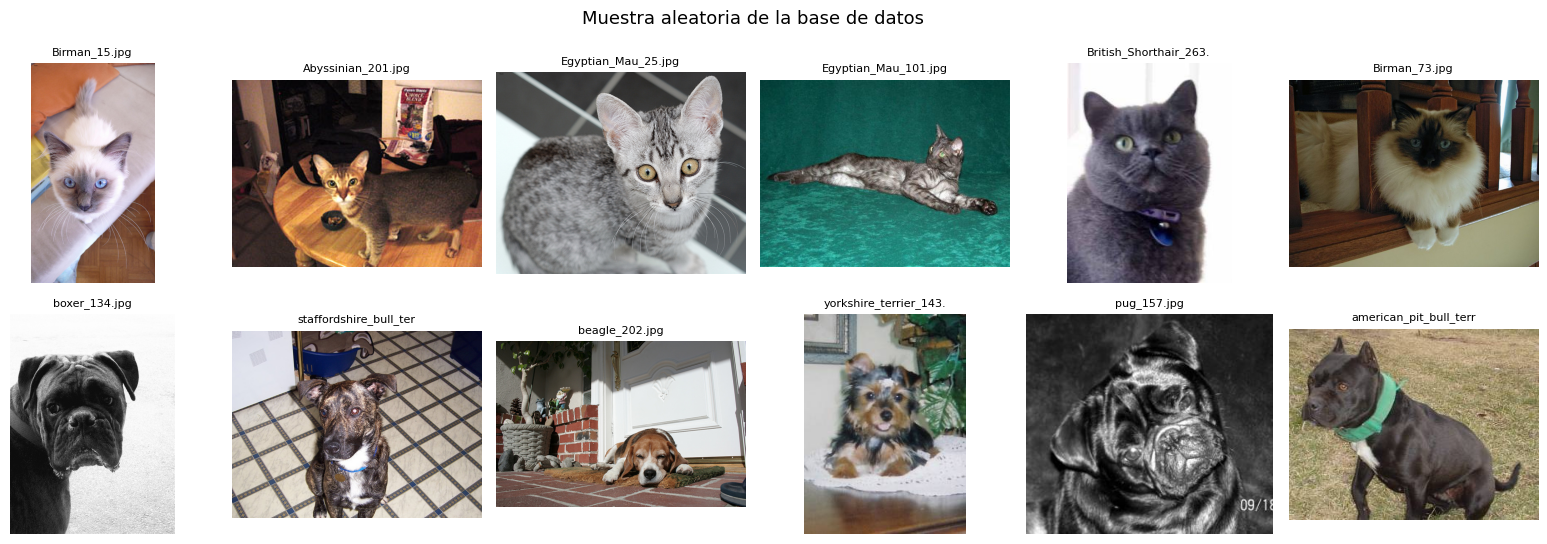

In [6]:
# Muestra visual de la base de datos
fig, axes = plt.subplots(2, 6, figsize=(16, 5.5))
rng = random.Random(SEED)

for row, cls in enumerate(CLASSES):
    sample = rng.sample(file_index[cls], 6)
    for col, fname in enumerate(sample):
        img = Image.open(os.path.join(DATA_ROOT, cls, fname)).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].set_title(fname[:22], fontsize=8)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cls, fontsize=12)

fig.suptitle("Muestra aleatoria de la base de datos",
             fontsize=13)
plt.tight_layout()
plt.show()

### Observaciones del análisis exploratorio

- La base está **prácticamente balanceada** (~49 % gatos / ~51 % perros), así que se puede usar `CrossEntropyLoss` sin pesos por clase.
- **No hay imágenes corruptas**, pero sí unos pocos archivos `.mat` y algunas imágenes que no están en RGB; ambos casos quedan resueltos automáticamente.
- Los tamaños son muy heterogéneos
- Las imágenes son fotografías naturales con fondos variados, poses distintas y animales a diferentes escalas

## 4. Transformaciones y aumento de datos


In [7]:
IMG_SIZE = 128

# Medias y desviaciones estandar de ImageNet (por canal R, G, B)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Pipeline de entrenamiento
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.10)),
])

# Pipeline de validación
eval_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Transformaciones definidas.")
print(f"Resolucion de entrada a la red: {IMG_SIZE} x {IMG_SIZE} x 3 canales")

Transformaciones definidas.
Resolucion de entrada a la red: 128 x 128 x 3 canales


## 5. División estratificada: entrenamiento / validación / prueba


In [8]:
from sklearn.model_selection import train_test_split

# Dos vistas del MISMO directorio, cada una con su propia transformacion.
# ImageFolder asigna las etiquetas por orden alfabetico de las carpetas:
#   cats -> 0,  dogs -> 1
train_view = datasets.ImageFolder(DATA_ROOT, transform=train_transform)
eval_view = datasets.ImageFolder(DATA_ROOT, transform=eval_transform)

class_names = train_view.classes
targets = np.array(train_view.targets)
indices = np.arange(len(targets))

print(f"Clases detectadas   : {class_names}")
print(f"Mapeo clase -> indice: {train_view.class_to_idx}")
print(f"Total de imagenes    : {len(indices)}")

# Primera division: 70% entrenamiento / 30% restante
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=SEED, stratify=targets
)

# Segunda division: ese 30% se parte a la mitad -> 15% val / 15% test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=SEED, stratify=targets[temp_idx]
)

# Cada indice se aplica sobre la vista correcta
train_dataset = Subset(train_view, train_idx)   # CON aumento de datos
val_dataset = Subset(eval_view, val_idx)        # SIN aumento de datos
test_dataset = Subset(eval_view, test_idx)      # SIN aumento de datos

print("\nTamaño y composición de cada conjunto")
for name, idx in [("Entrenamiento", train_idx), ("Validacion", val_idx), ("Prueba", test_idx)]:
    counts = Counter(targets[idx])
    detail = ", ".join(f"{class_names[c]}: {counts[c]}" for c in sorted(counts))
    print(f"  {name:<14} {len(idx):>5} imagenes ({len(idx)/len(indices):.1%})  ->  {detail}")

# Verificacion de que no hay fugas entre conjuntos
assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0
print("\nVerificado: los tres conjuntos son disjuntos (no hay fuga de datos).")

Clases detectadas   : ['cats', 'dogs']
Mapeo clase -> indice: {'cats': 0, 'dogs': 1}
Total de imagenes    : 4895

Tamaño y composición de cada conjunto
  Entrenamiento   3426 imagenes (70.0%)  ->  cats: 1680, dogs: 1746
  Validacion       734 imagenes (15.0%)  ->  cats: 360, dogs: 374
  Prueba           735 imagenes (15.0%)  ->  cats: 360, dogs: 375

Verificado: los tres conjuntos son disjuntos (no hay fuga de datos).


In [10]:
#DataLoaders
BATCH_SIZE = 64
NUM_WORKERS = 2 if device.type == "cuda" else 0

common_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == "cuda"),
)

train_loader = DataLoader(train_dataset, shuffle=True, drop_last=True, **common_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **common_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **common_kwargs)

print(f"Tamaño de lote: {BATCH_SIZE}")
print(f"Lotes por epoca -> entrenamiento: {len(train_loader)}, "
      f"validación: {len(val_loader)}, prueba: {len(test_loader)}")

# Inspeccion de un lote para confirmar formas y tipos
images, labels = next(iter(train_loader))
print(f"\nForma de un lote de imágenes: {tuple(images.shape)}  "
      f"-> (lote, canales, alto, ancho)")
print(f"Forma de un lote de etiquetas: {tuple(labels.shape)}")
print(f"Rango de valores tras normalizar: [{images.min():.2f}, {images.max():.2f}]")

Tamaño de lote: 64
Lotes por epoca -> entrenamiento: 53, validación: 12, prueba: 12

Forma de un lote de imágenes: (64, 3, 128, 128)  -> (lote, canales, alto, ancho)
Forma de un lote de etiquetas: (64,)
Rango de valores tras normalizar: [-2.12, 2.64]


## 7. Arquitectura de la red neuronal convolucional


In [11]:
def conv_block(in_channels, out_channels):
    """Bloque [Conv --> BatchNorm --> ReLU] x2 --> MaxPool.

    bias=False
    """
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )


class CatDogCNN(nn.Module):
    """Red convolucional para clasificacion binaria gato / perro."""

    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()


        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        return self.classifier(x)


model = CatDogCNN(num_classes=len(class_names)).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parametros totales   : {total_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")
print(f"Modelo alojado en    : {next(model.parameters()).device}")
print(model)

Parametros totales   : 1,206,498
Parametros entrenables: 1,206,498
Modelo alojado en    : cuda:0
CatDogCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): Bat

In [12]:

model.eval()
with torch.no_grad():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(device)
    dummy_out = model(dummy)

print(f"Entrada: {tuple(dummy.shape)}  ->  Salida: {tuple(dummy_out.shape)}")
print(f"Salida esperada: (4, {len(class_names)}). Arquitectura correcta.")

Entrada: (4, 3, 128, 128)  ->  Salida: (4, 2)
Salida esperada: (4, 2). Arquitectura correcta.


## 8. Función de cálculo de accuracy


In [14]:
@torch.no_grad()
def evaluate(model, loader, criterion, device, return_predictions=False):
    """Calcula accuracy y perdida promedio sobre un DataLoader.

    """
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if return_predictions:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    accuracy = correct / total
    avg_loss = running_loss / total

    if return_predictions:
        return (accuracy, avg_loss,
                torch.cat(all_labels).numpy(), torch.cat(all_preds).numpy())
    return accuracy, avg_loss


# Comprobación con el modelo sin entrenar
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
baseline_acc, baseline_loss = evaluate(model, val_loader, criterion, device)

print(f"Accuracy del modelo SIN entrenar: {baseline_acc:.4f}")
print(f"Perdida  del modelo SIN entrenar: {baseline_loss:.4f}")

Accuracy del modelo SIN entrenar: 0.5095
Perdida  del modelo SIN entrenar: 0.6930


In [15]:
print("\nComo se esperaba, ronda 0.50")
print("Esta es la linea base que el entrenamiento debe superar.")


Como se esperaba, ronda 0.50
Esta es la linea base que el entrenamiento debe superar.


## 9. Función de entrenamiento

In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Ejecuta una epoca completa de entrenamiento.

    """
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return correct / total, running_loss / total


print("Funcion de entrenamiento definida.")
print("Incluye: model.train(), optimizer.zero_grad(), datos y modelo en GPU.")

Funcion de entrenamiento definida.
Incluye: model.train(), optimizer.zero_grad(), datos y modelo en GPU.


## 10. Entrenamiento del modelo


In [17]:
EPOCHS = 40
LEARNING_RATE = 3e-3
WEIGHT_DECAY = 1e-4

set_seed()
model = CatDogCNN(num_classes=len(class_names)).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.25,
)

history = {"train_acc": [], "train_loss": [], "val_acc": [], "val_loss": [], "lr": []}
best_val_acc = 0.0
best_epoch = -1
BEST_MODEL_PATH = "best_catdog_cnn.pt"

print(f"Entrenando en: {device}")
print(f"Epocas: {EPOCHS} | Lote: {BATCH_SIZE} | LR maximo: {LEARNING_RATE}\n")
print(f"{'Epoca':>5} | {'Perd.Ent':>9} | {'Acc.Ent':>8} | "
      f"{'Perd.Val':>9} | {'Acc.Val':>8} | {'LR':>8} | {'Tiempo':>7}")
print("-" * 76)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Entrenamiento
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_acc, train_loss = correct / total, running_loss / total

    #  Validación
    val_acc, val_loss = evaluate(model, val_loader, criterion, device)

    current_lr = optimizer.param_groups[0]["lr"]
    history["train_acc"].append(train_acc)
    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    #  Guardar el mejor modelo hasta ahora
    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        flag = "  <- mejor"

    elapsed = time.time() - epoch_start
    print(f"{epoch:>5} | {train_loss:>9.4f} | {train_acc:>8.4f} | "
          f"{val_loss:>9.4f} | {val_acc:>8.4f} | {current_lr:>8.2e} | "
          f"{elapsed:>6.1f}s{flag}")

total_time = time.time() - start_time
print("-" * 76)
print(f"Entrenamiento terminado en {total_time/60:.1f} minutos.")
print(f"Mejor accuracy de validacion: {best_val_acc:.4f} (epoca {best_epoch})")

Entrenando en: cuda
Epocas: 40 | Lote: 64 | LR maximo: 0.003

Epoca |  Perd.Ent |  Acc.Ent |  Perd.Val |  Acc.Val |       LR |  Tiempo
----------------------------------------------------------------------------
    1 |    0.6967 |   0.5669 |    0.6432 |   0.6471 | 1.91e-04 |   23.0s  <- mejor
    2 |    0.6698 |   0.6067 |    0.6619 |   0.6185 | 3.96e-04 |   24.0s
    3 |    0.6572 |   0.6282 |    0.6433 |   0.6117 | 7.16e-04 |   25.6s
    4 |    0.6551 |   0.6306 |    0.6445 |   0.6471 | 1.12e-03 |   23.4s
    5 |    0.6543 |   0.6262 |    0.6380 |   0.6144 | 1.56e-03 |   22.6s
    6 |    0.6434 |   0.6415 |    0.9268 |   0.5858 | 2.01e-03 |   23.6s
    7 |    0.6321 |   0.6610 |    0.6012 |   0.6839 | 2.41e-03 |   23.5s  <- mejor
    8 |    0.6117 |   0.6733 |    1.0910 |   0.5436 | 2.73e-03 |   23.4s
    9 |    0.6112 |   0.6857 |    0.5778 |   0.7030 | 2.93e-03 |   22.3s  <- mejor
   10 |    0.5961 |   0.7022 |    0.5789 |   0.7166 | 3.00e-03 |   23.8s  <- mejor
   11 |    0.5849 

In [18]:
# --- Respaldo del mejor modelo ------------------------------------------
import shutil
from google.colab import files

BACKUP_PATH = f"catdog_cnn_val{best_val_acc:.4f}_ep{best_epoch}.pt"
shutil.copy(BEST_MODEL_PATH, BACKUP_PATH)

'catdog_cnn_val0.9210_ep38.pt'

In [20]:
import json
with open("training_history.json", "w") as f:
    json.dump({"history": history,
               "best_val_acc": best_val_acc,
               "best_epoch": best_epoch}, f)

print(f"Respaldo creado: {BACKUP_PATH}")
print(f"Tamaño: {os.path.getsize(BACKUP_PATH) / 1024**2:.1f} MB")

files.download(BACKUP_PATH)
files.download("training_history.json")

Respaldo creado: catdog_cnn_val0.9210_ep38.pt
Tamaño: 4.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Curvas de aprendizaje

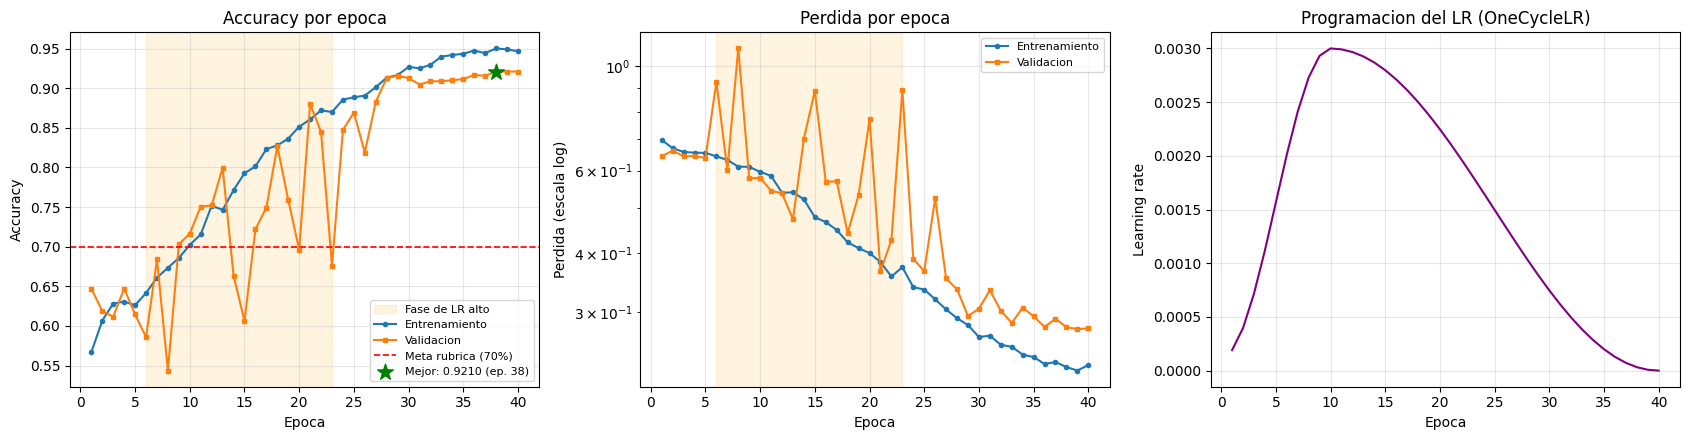

Brecha entrenamiento - validacion (ultima epoca): +0.0257
Brecha entrenamiento - validacion (mejor epoca) : +0.0292
Meta del 70% alcanzada por primera vez en la epoca: 9
Estabilidad final (ultimas 8 epocas): min 0.9087, max 0.9210, rango 0.0123


In [21]:
epochs_range = list(range(1, len(history["train_acc"]) + 1))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

high_lr = [e for e, lr in zip(epochs_range, history["lr"]) if lr > 0.6 * LEARNING_RATE]

# Accuracy
axes[0].axvspan(min(high_lr), max(high_lr), color="orange", alpha=0.12,
                label="Fase de LR alto")
axes[0].plot(epochs_range, history["train_acc"], marker="o", ms=3, label="Entrenamiento")
axes[0].plot(epochs_range, history["val_acc"], marker="s", ms=3, label="Validacion")
axes[0].axhline(0.70, color="red", ls="--", lw=1.2, label="Meta rubrica (70%)")
axes[0].scatter([best_epoch], [best_val_acc], color="green", s=140, zorder=5,
                marker="*", label=f"Mejor: {best_val_acc:.4f} (ep. {best_epoch})")
axes[0].set_xlabel("Epoca"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy por epoca"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

#  Perdida (escala log: el pico de la epoca 8 aplastaria el resto)
axes[1].axvspan(min(high_lr), max(high_lr), color="orange", alpha=0.12)
axes[1].plot(epochs_range, history["train_loss"], marker="o", ms=3, label="Entrenamiento")
axes[1].plot(epochs_range, history["val_loss"], marker="s", ms=3, label="Validacion")
axes[1].set_yscale("log")
axes[1].set_xlabel("Epoca"); axes[1].set_ylabel("Perdida (escala log)")
axes[1].set_title("Perdida por epoca"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(epochs_range, history["lr"], color="purple")
axes[2].set_xlabel("Epoca"); axes[2].set_ylabel("Learning rate")
axes[2].set_title("Programacion del LR (OneCycleLR)"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas de diagnostico
gap_final = history["train_acc"][-1] - history["val_acc"][-1]
gap_best = history["train_acc"][best_epoch - 1] - history["val_acc"][best_epoch - 1]
first_70 = next((e for e, a in zip(epochs_range, history["val_acc"]) if a >= 0.70), None)
last8 = history["val_acc"][-8:]

print(f"Brecha entrenamiento - validacion (ultima epoca): {gap_final:+.4f}")
print(f"Brecha entrenamiento - validacion (mejor epoca) : {gap_best:+.4f}")
print(f"Meta del 70% alcanzada por primera vez en la epoca: {first_70}")
print(f"Estabilidad final (ultimas 8 epocas): "
      f"min {min(last8):.4f}, max {max(last8):.4f}, rango {max(last8)-min(last8):.4f}")

## 12. Evaluación final sobre el conjunto de prueba


In [23]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Cargar los pesos de la mejor epoca
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.to(device)

test_acc, test_loss, y_true, y_pred = evaluate(
    model, test_loader, criterion, device, return_predictions=True
)

print("=" * 50)
print("           RESULTADO FINAL - CONJUNTO DE PRUEBA")
print("=" * 50)
print(f"  Imágenes evaluadas : {len(y_true)}")
print(f"  Accuracy de prueba : {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"  Perdida de prueba  : {test_loss:.4f}")
print(f"  Meta : 0.7000  (70.00 %)")
print("=" * 50)
if test_acc >= 0.70:
    print(f"  META ALCANZADA: se supera el umbral por "
          f"{(test_acc - 0.70)*100:.2f} puntos porcentuales.")
else:
    print("  Meta NO alcanzada. Sugerencias: aumentar EPOCHS, subir IMG_SIZE")
    print("  a 160, o ampliar los canales del modelo.")
print("=" * 50)

           RESULTADO FINAL - CONJUNTO DE PRUEBA
  Imágenes evaluadas : 735
  Accuracy de prueba : 0.9429  (94.29 %)
  Perdida de prueba  : 0.2424
  Meta : 0.7000  (70.00 %)
  META ALCANZADA: se supera el umbral por 24.29 puntos porcentuales.


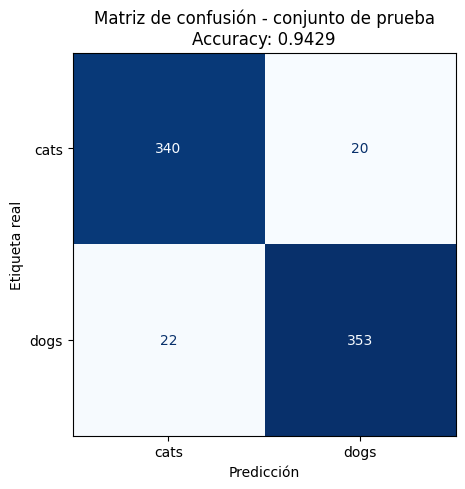


Reporte de clasificación
              precision    recall  f1-score   support

        cats     0.9392    0.9444    0.9418       360
        dogs     0.9464    0.9413    0.9439       375

    accuracy                         0.9429       735
   macro avg     0.9428    0.9429    0.9428       735
weighted avg     0.9429    0.9429    0.9429       735

cats  : 340/360 correctas  (94.44%)  -  20 errores
dogs  : 353/375 correctas  (94.13%)  -  22 errores


In [24]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Matriz de confusión - conjunto de prueba\nAccuracy: {test_acc:.4f}")
ax.set_xlabel("Predicción"); ax.set_ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

print("\nReporte de clasificación")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Desglose de errores por clase
for i, cls in enumerate(class_names):
    total_cls = cm[i].sum()
    errors = total_cls - cm[i, i]
    print(f"{cls:<6}: {cm[i, i]}/{total_cls} correctas  "
          f"({cm[i, i]/total_cls:.2%})  -  {errors} errores")

## 13. Inspección visual de predicciones

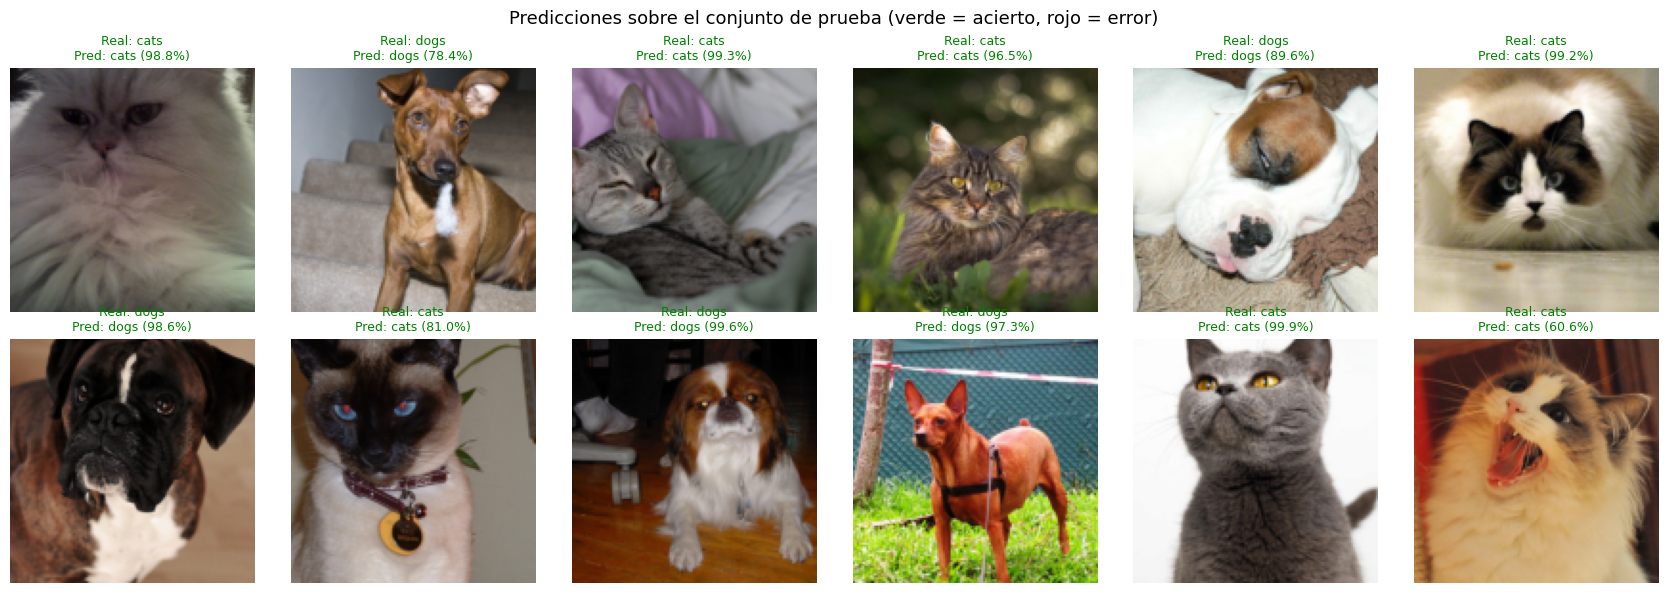

In [25]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


model.eval()
images, labels = next(iter(test_loader))
with torch.no_grad():
    logits = model(images.to(device))
    probs = torch.softmax(logits, dim=1)
    confidences, preds = probs.max(dim=1)

preds, confidences = preds.cpu(), confidences.cpu()

n_show = 12
fig, axes = plt.subplots(2, 6, figsize=(17, 6))
for i, ax in enumerate(axes.flat[:n_show]):
    ax.imshow(denormalize(images[i]))
    ok = preds[i].item() == labels[i].item()
    ax.set_title(
        f"Real: {class_names[labels[i]]}\n"
        f"Pred: {class_names[preds[i]]} ({confidences[i]:.1%})",
        fontsize=9, color=("green" if ok else "red"),
    )
    ax.axis("off")

fig.suptitle("Predicciones sobre el conjunto de prueba "
             "(verde = acierto, rojo = error)", fontsize=13)
plt.tight_layout()
plt.show()

Total de errores en el conjunto de prueba: 42


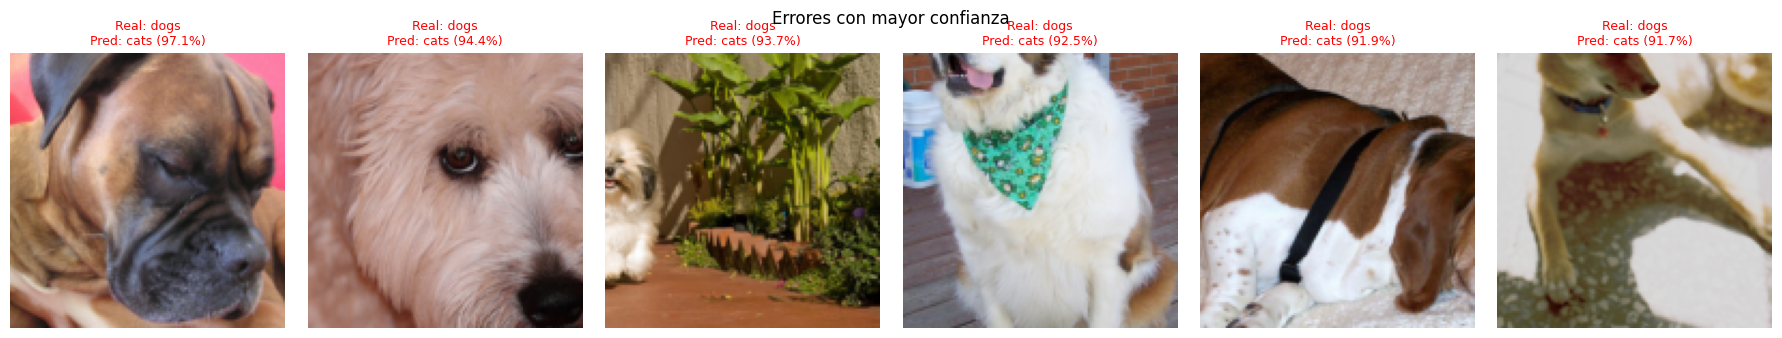

In [26]:
model.eval()
wrong = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)
        conf, preds = probs.max(dim=1)
        preds, conf = preds.cpu(), conf.cpu()
        mask = preds != labels
        for img, true_lbl, pred_lbl, c in zip(images[mask], labels[mask],
                                              preds[mask], conf[mask]):
            wrong.append((c.item(), img, true_lbl.item(), pred_lbl.item()))

wrong.sort(key=lambda t: t[0], reverse=True)
print(f"Total de errores en el conjunto de prueba: {len(wrong)}")

if wrong:
    n = min(6, len(wrong))
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.4))
    axes = np.atleast_1d(axes)
    for ax, (conf, img, true_lbl, pred_lbl) in zip(axes, wrong[:n]):
        ax.imshow(denormalize(img))
        ax.set_title(f"Real: {class_names[true_lbl]}\n"
                     f"Pred: {class_names[pred_lbl]} ({conf:.1%})",
                     fontsize=9, color="red")
        ax.axis("off")
    fig.suptitle("Errores con mayor confianza", fontsize=12)
    plt.tight_layout()
    plt.show()

---
## 14. Conclusiones

### Resultado

**Accuracy en el conjunto de prueba: 94.29 %** (693/735 imágenes), superando por 24.29 puntos el 70 %. Pérdida de prueba: 0.2424.

| Conjunto | Accuracy |
|---|---|
| Línea base (modelo sin entrenar) | 50.95 % |
| Validación (mejor época, la 38) | 92.10 % |
| **Prueba** | **94.29 %** |

El resultado de prueba supera al de validación en 2.2 puntos. Con conjuntos de ~735 imágenes el error estándar ronda ±0.9 puntos.

### Desempeño equilibrado entre clases

| Clase | Correctas | Recall | F1 |
|---|---|---|---|
| cats | 340/360 | 94.44 % | 0.9418 |
| dogs | 353/375 | 94.13 % | 0.9439 |

Sólo **0.31 puntos** de diferencia en recall, y la matriz de confusión es simétrica (20 vs. 22 errores). El modelo no adoptó el atajo de favorecer a la clase mayoritaria: aprendió rasgos discriminativos reales.

### Sin sobreajuste

La brecha entre entrenamiento y validación es de **2.6 puntos** en la última época (2.9 en la mejor).

### Análisis de los 42 errores

Los errores no son aleatorios. Los seis más confiados son **todos perros clasificados como gatos**, y comparten patrones claros:

- **Encuadre muy cercano** — sólo hocico y ojos, sin silueta ni orejas visibles.
- **Pelaje claro, largo y esponjado** — texturalmente idéntico a razas felinas como Persa o Ragdoll.
- **Poses no canónicas** — animales acostados, enroscados o vistos desde arriba.
- **Sujeto pequeño en el encuadre**, dominado por el fondo.

De aquí se deduce que **el modelo depende de la silueta completa y de rasgos faciales estructurales**; cuando el encuadre las elimina, se apoya en la textura del pelaje, que es precisamente donde ambas clases se traslapan.


### Decisiones de diseño

| Decisión | Justificación |
|---|---|
| CNN de 4 bloques (~1.2 M parámetros) | Capacidad suficiente sin memorizar 3 426 imágenes |
| Dos `Conv2d` 3×3 en vez de una 5×5 | Mismo campo receptivo con 28% menos parámetros y una no linealidad extra |
| ReLU y LeakyReLU en todas las capas | No saturan, evitando el desvanecimiento del gradiente de Sigmoid/Tanh |
| `BatchNorm` tras cada convolución | Estabiliza el entrenamiento y permite un learning rate más alto |
| Global average pooling | Recorta 64× los parámetros densos, que es donde más se sobreajusta |
| División estratificada 70/15/15 | El conjunto de prueba no influyó en ninguna decisión |
| Selección del mejor epoch por validación | Evita reportar un modelo ya sobreajustado |